# ProteinGym

In [10]:
# conda create --name proteingym_env --file environments/proteingym_env.txt -c conda-forge -c bioconda -c pytorch
# !pip install proteingym -y

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/grid/koo/home/schilder/projects/GenomeEncoder/')
import pandas as pd

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.proteingym as pg 

## Download data

In [2]:
proteins_df = pg.merge_resources()
proteins_df

Gathering resources: 100%|██████████| 2/2 [00:03<00:00,  1.73s/it]


,protein,RefSeq peptide ID,source_file,source_type,experiment_id
0,NP_001845.3,NP_001845,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001845.3
1,NP_004161.4,NP_004161,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_004161.4
2,NP_550438.1,NP_550438,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_550438.1
3,NP_056414.1,NP_056414,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_056414.1
4,NP_003292.1,NP_003292,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_003292.1
...,...,...,...,...,...
4075,NP_001243805.1,NP_001243805,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001243805.1
4076,NP_005984.3,NP_005984,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_005984.3
4077,UPI000013CF5D,UPI000013CF5D,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI000013CF5D
4078,NP_060297.1,NP_060297,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_060297.1


## Count variants

In [3]:
resources_df = pg.get_resources_df()
pg_resources = pg.download_resources(
    resources_df.loc[resources_df['Filename'].isin(
        ['clinical_ProteinGym_substitutions.zip', 
         'clinical_ProteinGym_indels.zip']
        )],
    error=False)
pg.count_resources(pg_resources)

Gathering resources: 100%|██████████| 2/2 [00:02<00:00,  1.45s/it]


{'clinical_ProteinGym_substitutions': '2525 file(s)',
 'clinical_ProteinGym_indels': '1555 file(s)'}

In [77]:
def get_variant_ratios(df,
                       protein_col='protein',
                       score_col='DMS_bin_score',
                       mutant_col='mutant',
                       fill_value=0):
    df = df.copy()
    # drop rows that are all NaN
    df = df.dropna(axis=1, how='all')
    print("Proteins:",df[protein_col].nunique())
    df2 = df.groupby([protein_col, score_col])[mutant_col].count().unstack(fill_value=fill_value)
    df2['total'] = df2['Benign'] + df2['Pathogenic'] 

    print('Pathogenic:',sum(df2['Pathogenic']))
    print('Benign:',sum(df2['Benign']))
    print('Pathogenic/Benign:',sum(df2['Pathogenic']) / sum(df2['Benign']))
    df2['pathogenic_ratio'] = (df2['Pathogenic']) / (df2['total'] + 1e-6)
    df2.sort_values('pathogenic_ratio', ascending=False, inplace=True)
    df2.hist('pathogenic_ratio', bins=100) 
    return df2

### Substitutions

In [7]:
clinical_subs_df = pg.concat_csvs(
    pg_resources, 
    key='clinical_ProteinGym_substitutions',
    )

Reading files in clinical_ProteinGym_substitutions: 100%|██████████| 2525/2525 [00:47<00:00, 53.35it/s]


Proteins: 2525
Pathogenic: 32000
Benign: 30727
Pathogenic/Benign: 1.0414293617990693


DMS_bin_score,Benign,Pathogenic,total,pathogenic_ratio
protein,,,,
NP_000268.1,2,397,399,0.994987
NP_005563.1,1,157,158,0.993671
NP_006000.2,1,149,150,0.993333
NP_835366.1,1,78,79,0.987342
NP_000153.1,2,146,148,0.986486
...,...,...,...,...
NP_109590.3,199,3,202,0.014851
NP_060798.2,133,2,135,0.014815
NP_001094383.2,79,1,80,0.012500


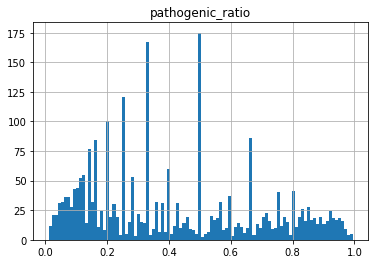

In [31]:
get_variant_ratios(clinical_subs_df)

In [21]:
# Report stats
haplotypes_per_protein = 37.5
print(clinical_subs_df['protein'].nunique()*haplotypes_per_protein,
      "haplotypes across",len(clinical_subs_df), 
      "substitutions in",clinical_subs_df['protein'].nunique(),"proteins")

sum(clinical_subs_df.groupby('mutant').size()*haplotypes_per_protein)

94687.5 haplotypes across 62727 substitutions in 2525 proteins


2352262.5

In [ ]:
# Using all benign/pathogenic variants per protein
print(sum(clinical_subs_df.groupby('protein').size()*haplotypes_per_protein))
# Using only 1 benign/pathogenic variant per protein
print(clinical_subs_df['protein'].nunique()*2*haplotypes_per_protein)

2352262.5
189375.0


### Indels

In [ ]:
clinical_indels_df = pg.concat_csvs(
    pg_resources, 
    key='clinical_ProteinGym_indels')
clinical_indels_df['protein'] = clinical_indels_df['source_file'].str.replace('.csv', '', regex=False)

Reading files in clinical_ProteinGym_indels: 100%|██████████| 1555/1555 [00:16<00:00, 95.40it/s] 


Proteins: 1555
Pathogenic: 1742
Benign: 297
Pathogenic/Benign: 5.865319865319865


DMS_score_bin,0,Benign,Pathogenic,total,pathogenic_ratio
protein,,,,,
NP_000518.1,0,0,31,31,1.0
NP_001159435.1,0,0,21,21,1.0
NP_001009944.3,0,0,18,18,1.0
NP_000129.3,0,0,16,16,1.0
NP_000240.1,0,0,14,14,1.0
...,...,...,...,...,...
UPI000013CCD8,0,0,0,0,0.0
UPI000013CCDF,0,0,0,0,0.0
UPI000013CD7C,0,0,0,0,0.0


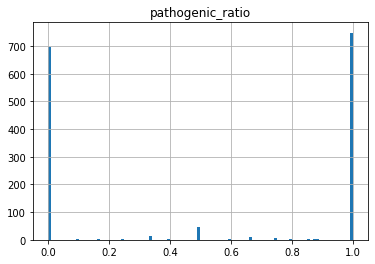

In [48]:
get_variant_ratios(clinical_indels_df,
                    score_col='DMS_score_bin',
                    mutant_col='VariationID')

In [14]:
# Report stats
haplotypes_per_protein = 37.5
print(clinical_indels_df['refseq_unique_id'].nunique()*haplotypes_per_protein,
      "estimated haplotypes across",len(clinical_indels_df), 
      "substitutions in",clinical_indels_df['refseq_unique_id'].nunique(),"proteins")
print("Total estimated haplotype sequences:",
      clinical_indels_df['refseq_unique_id'].nunique()*haplotypes_per_protein)

32175.0 haplotype sequences across 2878 substitutions in 858 proteins


In [ ]:
# Using all benign/pathogenic variants per protein
print(sum(clinical_indels_df.groupby('refseq_unique_id').size()*haplotypes_per_protein))
# Using only 1 benign/pathogenic variant per protein
print(clinical_indels_df['refseq_unique_id'].nunique()*2*haplotypes_per_protein)

76462.5
64350.0
